##🐱🐶 Task 4: Cat vs Dog Image Classification using Convolutional Neural Network (CNN)
##📌 Objective

The objective of this project is to develop a Deep Learning model capable of classifying images as either cats or dogs using a Convolutional Neural Network (CNN). The project covers the complete workflow, including image preprocessing, data augmentation, model training, evaluation, and prediction using TensorFlow and Keras

##📖 Step 1: Import Required Libraries

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


##📂 Step 2: Load and Explore the Dataset

In [20]:
import os
import zipfile

# Extract Dataset
zip_path = "/content/archive.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

# Dataset Path
dataset_path = "/content/PetImages"

# Display folders
print("\nFolders in Dataset:", os.listdir(dataset_path))

# Count images
cat_count = len(os.listdir(os.path.join(dataset_path, "Cat")))
dog_count = len(os.listdir(os.path.join(dataset_path, "Dog")))

print(f"\nNumber of Cat Images: {cat_count}")
print(f"Number of Dog Images: {dog_count}")

Dataset extracted successfully!

Folders in Dataset: ['Dog', 'Cat']

Number of Cat Images: 12501
Number of Dog Images: 12501


##🖼️ Step 3: Display Sample Images

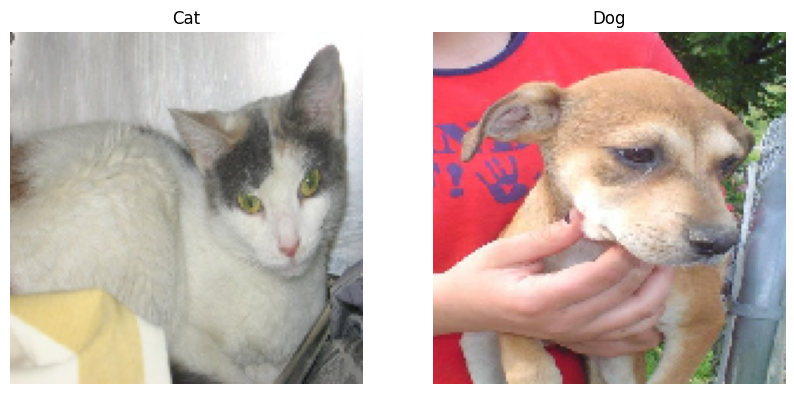

In [21]:
import random
from tensorflow.keras.preprocessing import image

# Display sample images
plt.figure(figsize=(10, 10))

categories = ["Cat", "Dog"]

for i, category in enumerate(categories):
    folder_path = os.path.join(dataset_path, category)

    # Select a random image
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = image.load_img(img_path, target_size=(150, 150))

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

##🧹 Step 4: Remove Corrupted Images

In [22]:
from PIL import Image

# Remove corrupted images
removed_images = 0

for category in ["Cat", "Dog"]:
    folder_path = os.path.join(dataset_path, category)

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        try:
            img = Image.open(file_path)
            img.verify()
        except:
            os.remove(file_path)
            removed_images += 1

print(f"Corrupted images removed: {removed_images}")

# Count images after cleaning
cat_count = len(os.listdir(os.path.join(dataset_path, "Cat")))
dog_count = len(os.listdir(os.path.join(dataset_path, "Dog")))

print(f"Cat Images: {cat_count}")
print(f"Dog Images: {dog_count}")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted images removed: 4
Cat Images: 12499
Dog Images: 12499


##🔄 Step 5: Data Preprocessing and Augmentation

In [23]:
# Data Preprocessing and Data Augmentation

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("\nDataset Loaded Successfully!")
print("Classes:", train_generator.class_indices)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.

Dataset Loaded Successfully!
Classes: {'Cat': 0, 'Dog': 1}


##🧠 Step 6: Build the CNN Model

In [24]:
# Build the CNN Model

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

print("CNN Model Created Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Created Successfully!


##⚙️ Step 7: Compile the CNN Model

In [25]:
# Compile the CNN Model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

# Display Model Summary
model.summary()

Model Compiled Successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

##🚀 Step 8: Train the CNN Model

In [27]:
# Train the CNN Model

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

print("Model Training Completed Successfully!")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1040s 2s/step - accuracy: 0.7395 - loss: 0.5241 - val_accuracy: 0.7553 - val_loss: 0.5026
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1054s 2s/step - accuracy: 0.7821 - loss: 0.4652 - val_accuracy: 0.8057 - val_loss: 0.4207
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1078s 2s/step - accuracy: 0.7961 - loss: 0.4412 - val_accuracy: 0.7955 - val_loss: 0.4345
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1136s 2s/step - accuracy: 0.8145 - loss: 0.4139 - val_accuracy: 0.8159 - val_loss: 0.4084
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1004s 2s/step - accuracy: 0.8248 - loss: 0.3899 - val_accuracy: 0.8413 - val_loss: 0.3794
Model Training Completed Successfully!


##📈 Step 9: Visualize Training Performance

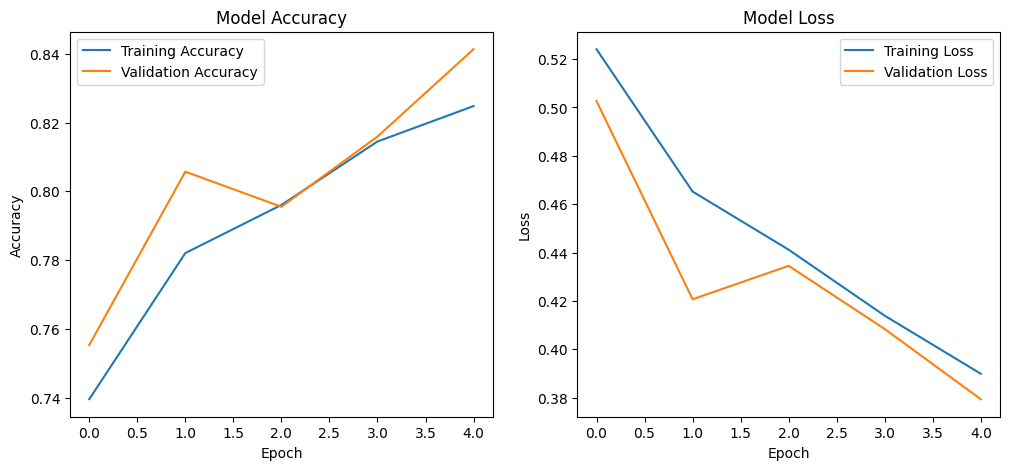

In [28]:
# Plot Accuracy and Loss

import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

##📊 Step 10: Evaluate the Model

In [29]:
# Evaluate Model

loss, accuracy = model.evaluate(validation_generator)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 543ms/step - accuracy: 0.8309 - loss: 0.3783

Validation Loss: 0.3783
Validation Accuracy: 83.09%


##📋 Step 11: Generate Confusion Matrix and Classification Report

In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
predictions = model.predict(validation_generator)
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)

true_classes = validation_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:\n")
print(cm)

print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes))

157/157 ━━━━━━━━━━━━━━━━━━━━ 86s 543ms/step
Confusion Matrix:

[[2135  364]
 [ 479 2020]]

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.85      0.84      2499
           1       0.85      0.81      0.83      2499

    accuracy                           0.83      4998
   macro avg       0.83      0.83      0.83      4998
weighted avg       0.83      0.83      0.83      4998



##📉 Step 12: Visualize Confusion Matrix

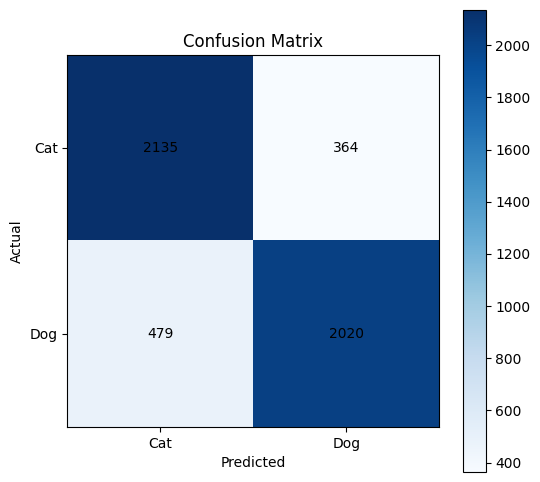

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Cat','Dog'])
plt.yticks(tick_marks, ['Cat','Dog'])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.show()

##🔍 Step 13: Predict on a New Image

In [34]:
from google.colab import files

uploaded = files.upload()

Saving dog.jpg to dog (1).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: Dog 🐶


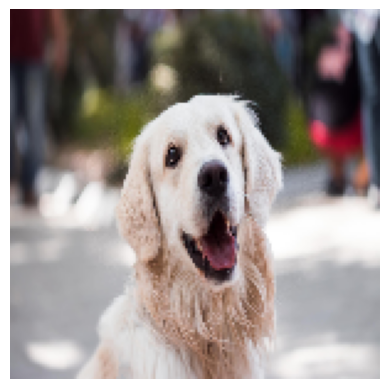

In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis('off')

if prediction[0][0] > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")

##💾 Step 14: Save the Trained Model


In [36]:
model.save("cat_dog_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


##✅ Conclusion

In this project, a Convolutional Neural Network (CNN) was successfully developed to classify images of cats and dogs. The project involved image preprocessing, removal of corrupted images, data augmentation, model training, evaluation, and prediction using TensorFlow and Keras.

This task provided practical experience in Deep Learning and Computer Vision while demonstrating the complete workflow of building an image classification model. It also strengthened my understanding of CNN architecture, image preprocessing techniques, model evaluation, and real-world image classification applications.